# 모델을 불러와서 그림을 그리자

In [7]:
 # 나중에 바뀌어야 함 ./runs/MNIST{DIGITS_STR}_{DIGIT}_ld{latent_dim}_{train_type}_{current_time}
import importlib
import matplotlib.pyplot as plt
from modules import QGAN2, Autoencoder # 초기 import
importlib.reload(QGAN2)  # 모듈 갱신

import torch
from torch.autograd import Variable

import numpy as np

import pennylane as qml

DIGITS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # 학습할 숫자들 설정
DIGITS_STR = ''.join(map(str, DIGITS))
TARGETS = [3, 5]
TARGETS_STR = ''.join(map(str, TARGETS))
for target in TARGETS:
    assert(target in DIGITS)

n_qubits = 5
output_qubits = 5
n_layers = 20
latent_dim = 16
assert(2**output_qubits >= latent_dim)
SEED_RANGE = 0.25

dev = qml.device("default.qubit", wires=n_qubits)

# 생성자 파라미터 초기화 및 모듈 불러오기
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/3, np.pi/3, (n_layers, n_qubits, 1))), requires_grad=True)
generator = QGAN2.QGAN2(n_qubits, output_qubits, n_layers, generator_initial_params, dev)

# generator 로딩
epoch = 171
base_dir = './runs/MNIST0123456789_35_ld16_InfoQGAN_Nov16_14_49_26'
generator_initial_params = torch.load(f'{base_dir}/params/generator_params_epoch{epoch}.pth')
generator.params = generator_initial_params

C:\Users\minkyu\AppData\Local\Temp\ipykernel_35468\736542389.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(f'{base_dir}/params/g

In [8]:
# autoencoder 모델 준비
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
autoencoder_epochs = 50
autoencoder_lr = 0.0001
autoencoder.load_state_dict(torch.load(f'savepoints/autoencoder_{DIGITS_STR}_{latent_dim}_ep{autoencoder_epochs}_lr{autoencoder_lr}.pth'))
autoencoder.eval()  # 평가 모드로 전환

C:\Users\minkyu\AppData\Local\Temp\ipykernel_35468\2404763708.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(f'savepoints/autoenc

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=6272, out_features=16, bias=True)
    (6): AbsoluteValueLayer()
    (7): NormalizeLayer()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=6272, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(8, 28, 28))
    (3): ConvTranspose2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Sigmoid()
  )
)

code qubit으로 그려보자

In [9]:
def generate_image(generator, seed):
    generator_output = generator.forward(seed)
    generator_output = generator_output.to(torch.float32)
    # latent vector만 추출  
    generator_output = generator_output[:, :latent_dim]
    # decoder을 사용하여 복구
    with torch.no_grad():
        reconstructed = autoencoder.decoder(generator_output)
    return reconstructed

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_output2(reconstructed, code1, code2):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
            axs[i, j].axis('off')

    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, f'latent {code2}', ha='center', fontsize=12)  # x축 라벨 (위쪽)
    fig.text(0.05, 0.5, f'latent {code1}', va='center', rotation='vertical', fontsize=12)  # y축 라벨 (왼쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # y축 화살표 (아래쪽으로)
    arrow_y = mpatches.FancyArrow(0.08, 0.9, 0, -0.8, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_y)

    # 제목 설정
    plt.suptitle(f"TARGETS={TARGETS_STR}/{DIGITS_STR} epoch={epoch} dim={latent_dim} code={code1}{code2}")
    plt.savefig(f'{base_dir}/ep{epoch}_code{code1}{code2}.png')
    plt.show()

def visualize_output1(reconstructed, code1):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(reconstructed[i*10+j].squeeze().detach().numpy(), cmap='gray')
            axs[i, j].axis('off')

    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, f'latent {code1}', ha='center', fontsize=12)  # x축 라벨 (위쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # 제목 설정
    plt.suptitle(f"TARGETS={TARGETS_STR}/{DIGITS_STR} epoch={epoch} dim={latent_dim} code={code1}")
    plt.savefig(f'{base_dir}/ep{epoch}_code{code1}.png')
    plt.show()

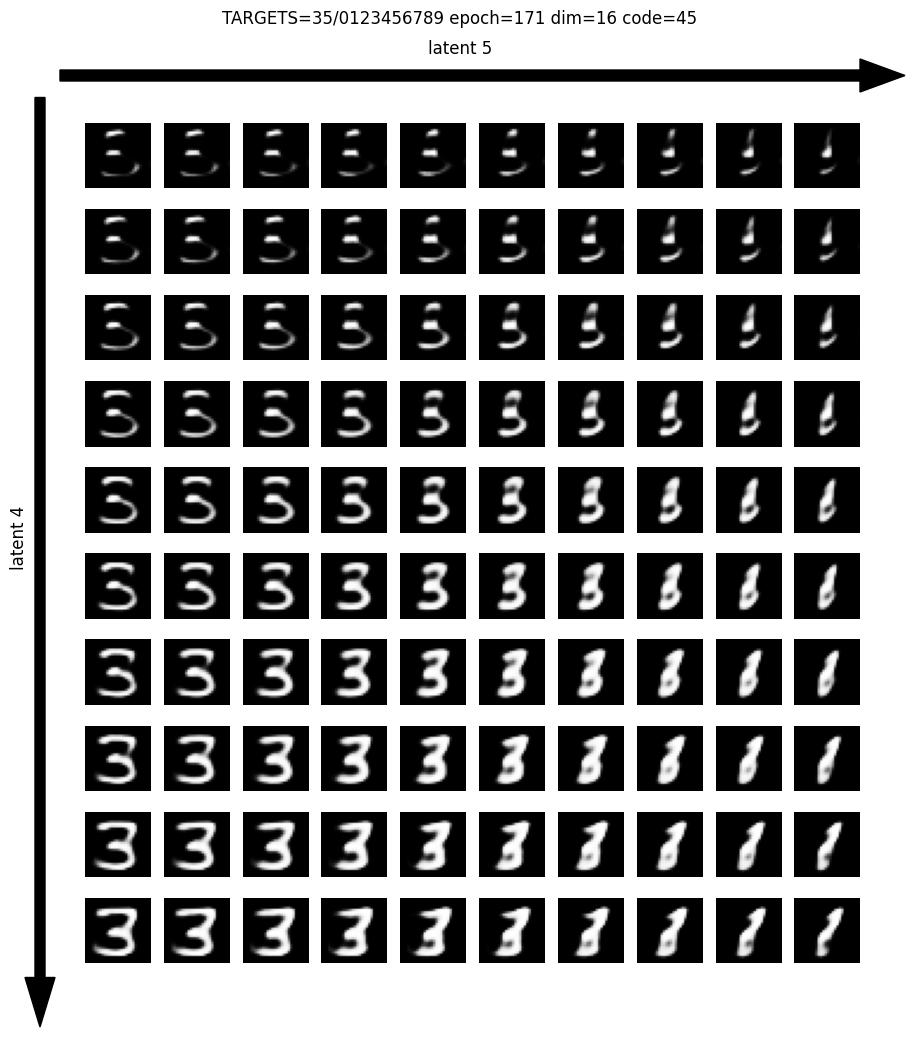

In [10]:
# generator_seed = np.random.uniform(-0.25, 0.25, (100, n_qubits)) # 원래 값 범위에서 1/4로 줄임.
generator_seed = np.zeros((100, n_qubits))

for i in range(100):
    r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
    generator_seed[i, -2] = SEED_RANGE * (-1 + 2 * r / 9)
    generator_seed[i, -1] = SEED_RANGE * (-1 + 2 * c / 9)
reconstructed = generate_image(generator, generator_seed)
visualize_output2(reconstructed, n_qubits-1, n_qubits)

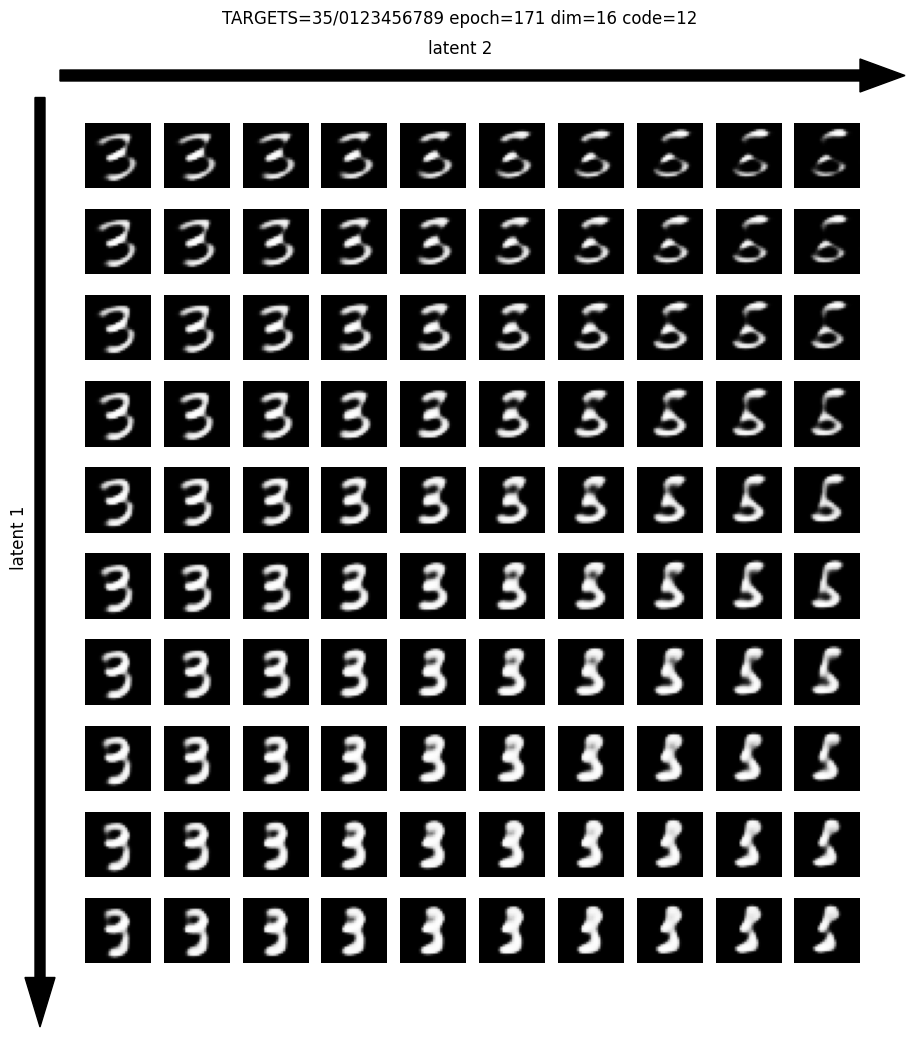

In [11]:
# generator_seed = np.random.uniform(-0.25, 0.25, (100, n_qubits)) # 원래 값 범위에서 1/4로 줄임.
generator_seed = np.zeros((100, n_qubits))

for i in range(100):
    r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
    generator_seed[i, 0] = SEED_RANGE * (-1 + 2 * r / 9)
    generator_seed[i, 1] = SEED_RANGE * (-1 + 2 * c / 9)
    
reconstructed = generate_image(generator, generator_seed)
visualize_output2(reconstructed, 1, 2)


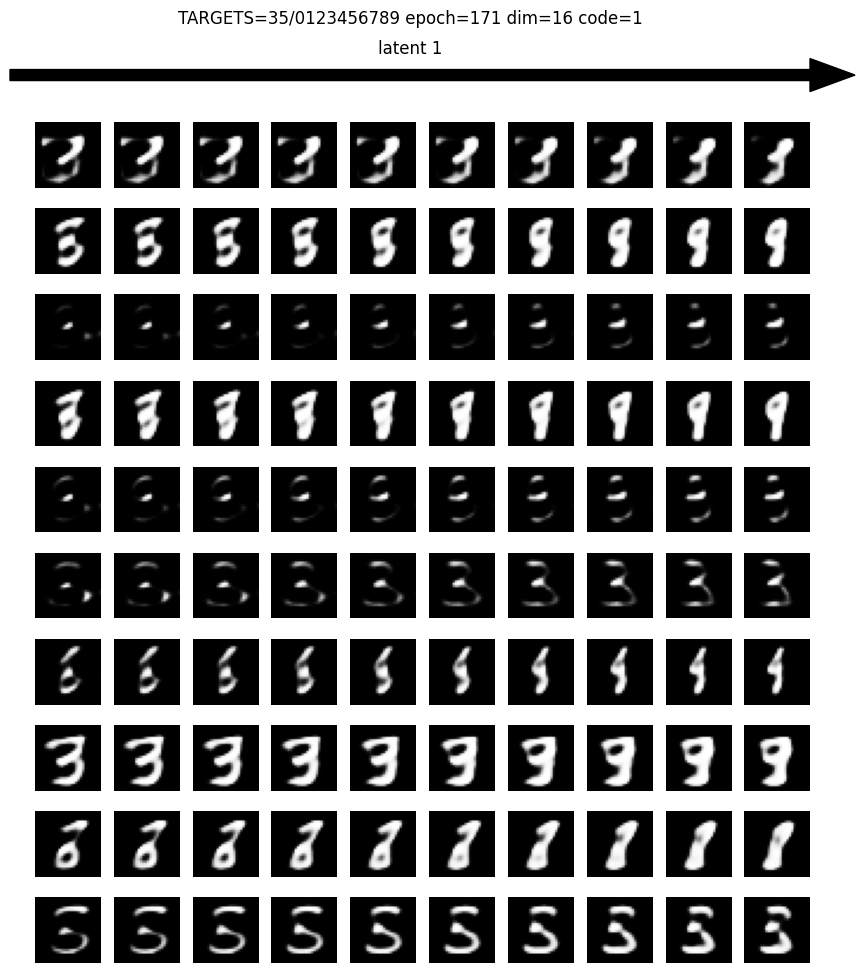

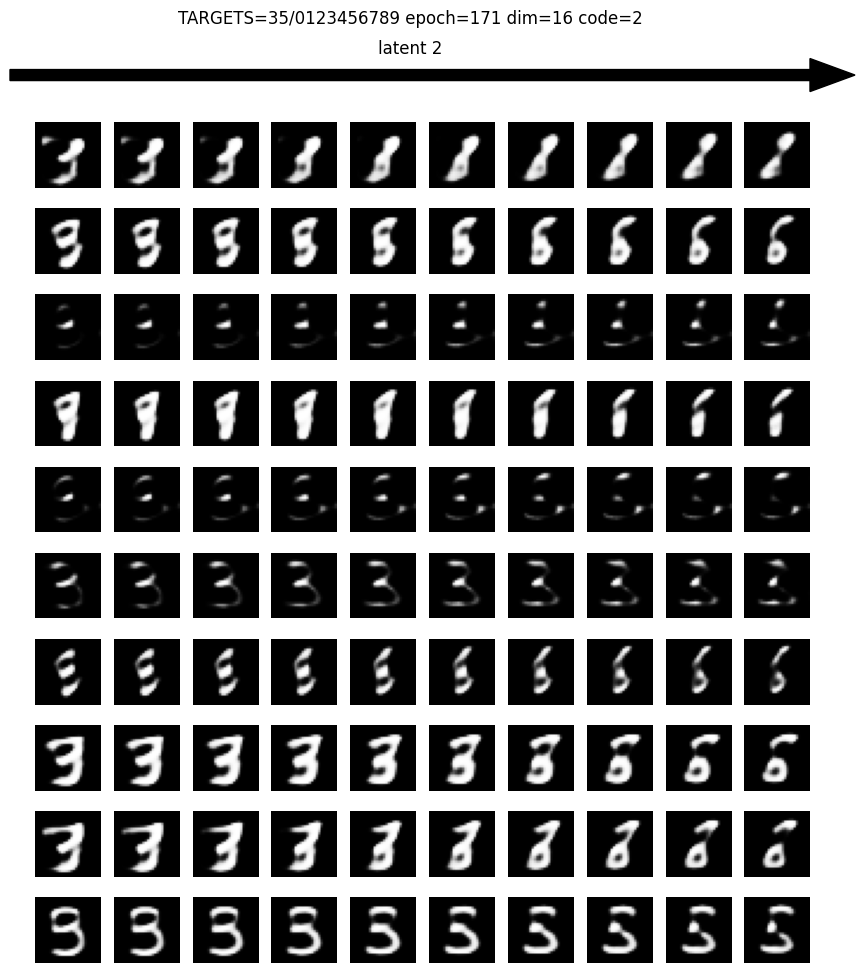

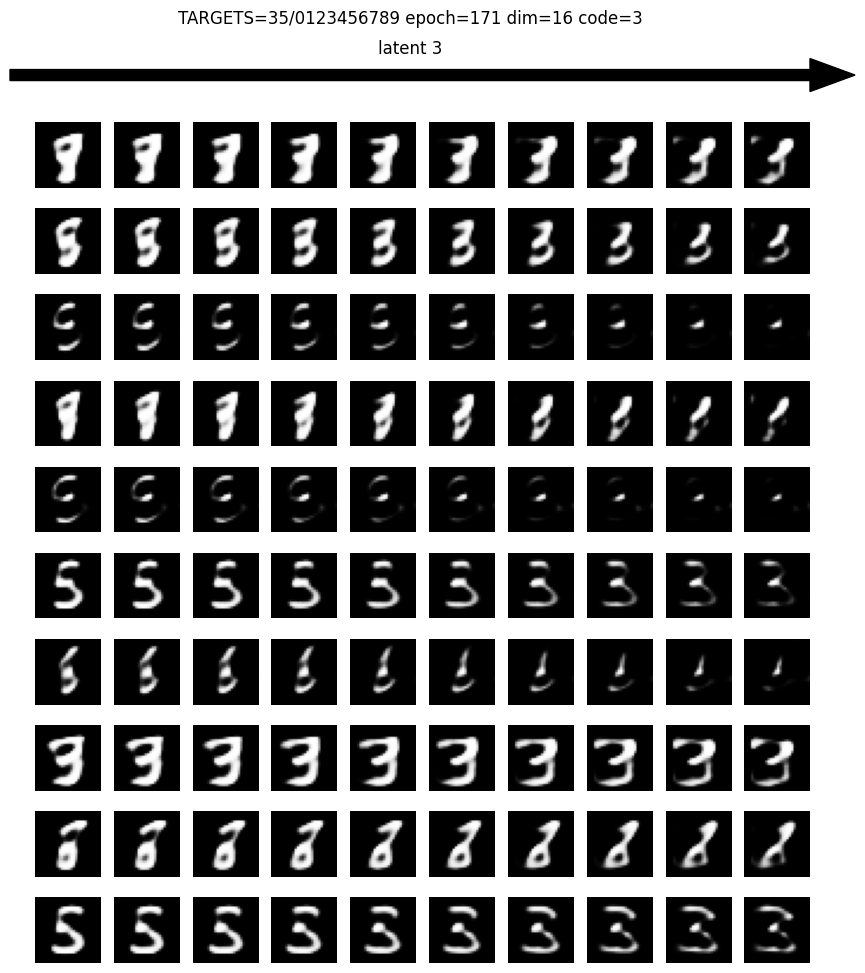

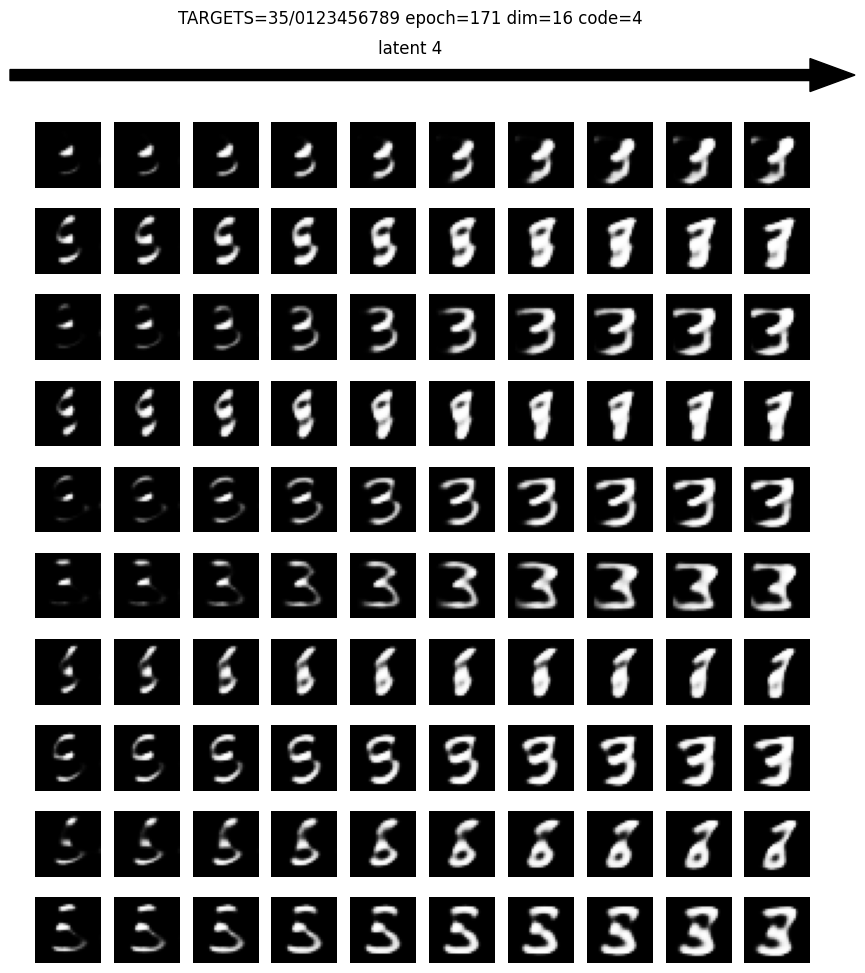

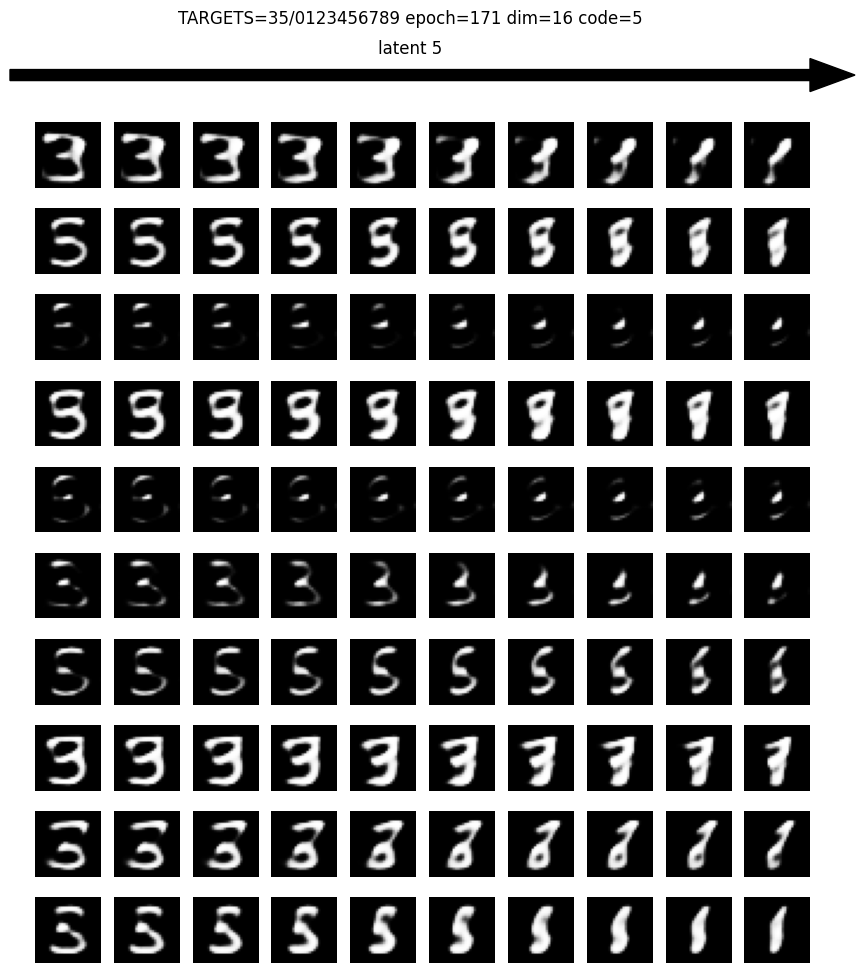

In [12]:
generator_seed = np.zeros((100, n_qubits))
base_seed = np.random.uniform(-SEED_RANGE, SEED_RANGE, (10, n_qubits))

for t in range(n_qubits):
    for i in range(100):
        r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
        generator_seed[i] = base_seed[r]
        generator_seed[i][t] = SEED_RANGE * (-1 + 2 * c / 9)
    reconstructed = generate_image(generator, generator_seed)
    visualize_output1(reconstructed, t+1)